<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_14_Winsorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winsorization technique

Winsorization is a statistical technique used in data analysis to handle extreme values, often called outliers. Instead of removing these outliers entirely, winsorization replaces them with values that are closer to the rest of the data. The goal is to reduce the impact of these extreme values on statistical measures and models without losing the information they might contain about the distribution's spread.

###1. The Problem:Outliers

Imagine you have a dataset of people's ages: 25, 30, 28, 32, 29, 95. The age 95 is quite different from the others – it's an outlier. Outliers can occur for various reasons:

Genuine extreme values: Some data points are naturally very high or low.

Measurement errors:Mistakes during data collection.

Data entry errors:Typos when entering data.

Unusual events: A one-time occurrence that significantly affects the data.

Outliers can significantly skew statistical calculations like the mean (average) and standard deviation (spread), potentially leading to misleading conclusions.

###2. What is Winsorization?

Winsorization involves setting the extreme values in a dataset to a specific percentile of the data itself. Think of it as "capping" or "squashing" the outliers inwards.

How it works:

Choose a percentage: You decide what percentage of the data from both ends (the lowest and the highest) you want to "winsorize." Common choices are 5% or 10% from each tail, resulting in a 90% or 80% winsorized dataset, respectively.

Identify the percentiles: Based on the chosen percentage, you find the corresponding percentile values in your sorted dataset. For example, for a 5% winsorization, you'd find the 5th percentile and the 95th percentile.

1.Replace the outliers:Any value below the lower percentile is replaced with the value of that lower percentile.
Any value above the upper percentile is replaced with the value of that upper percentile.

Example:

Let's take the age dataset: 25, 28, 29, 30, 32, 95.
If we apply a 10% winsorization (meaning 10% from the bottom and 10% from the top):

1.Sort the data: 25, 28, 29, 30, 32, 95

2.Determine the boundaries: With 6 data points, 10% of 6 is 0.6. We usually round this up to 1. So, we'll adjust the bottom 1 and the top 1 value.

3.Identify percentile values: The 1st value is 25, and the 6th value is 95.

4.Replace outliers:
The lowest 10% (the value 25) is replaced by the next value, 28.
The highest 10% (the value 95) is replaced by the preceding value, 32.

The winsorized dataset becomes: 28, 28, 29, 30, 32, 32.

Notice that the extreme values have been brought closer to the center of the data.

###3. Why Use Winsorization?

* Reduces the impact of outliers: It prevents extreme values from disproportionately influencing statistical results.

* Preserves data points: Unlike trimming (simply removing outliers), winsorization keeps all the original data points, which can be important, especially with small datasets.

* More robust statistics: Statistical measures calculated on winsorized data are often more stable and less sensitive to extreme fluctuations.

* Useful in specific fields: It's commonly used in finance, economics, and survey analysis where extreme values can be common but might not represent typical behavior.

###4. Winsorization vs. Trimming

It's important to distinguish winsorization from trimming (or truncation).

* Winsorization: Replaces outliers with the values at a specific percentile. The number of data points remains the same.

* Trimming: Removes the outliers from the dataset. The number of data points decreases.

When to use which:

* Use winsorization when you believe the outliers might contain some valuable information about the distribution's spread or when you want to maintain the original sample size.

* Use trimming when you strongly suspect that the outliers are due to errors or are fundamentally different from the rest of the data and should not be considered in the analysis.

###5. Choosing the Winsorization Level

The percentage of data you choose to winsorize depends on the specific dataset and the goals of your analysis. There's no one-size-fits-all answer. Common approaches include:

* Standard levels: Starting with 5% or 10% from each tail.

* Domain knowledge: Using your understanding of the data and the field to determine reasonable cut-offs.

* Sensitivity analysis: Trying different winsorization levels and observing how the results change.

In summary, winsorization is a helpful technique for dealing with outliers by moderating their impact without discarding them entirely. It provides a balance between retaining data and reducing the distortion caused by extreme values, leading to more robust and reliable data analysis.


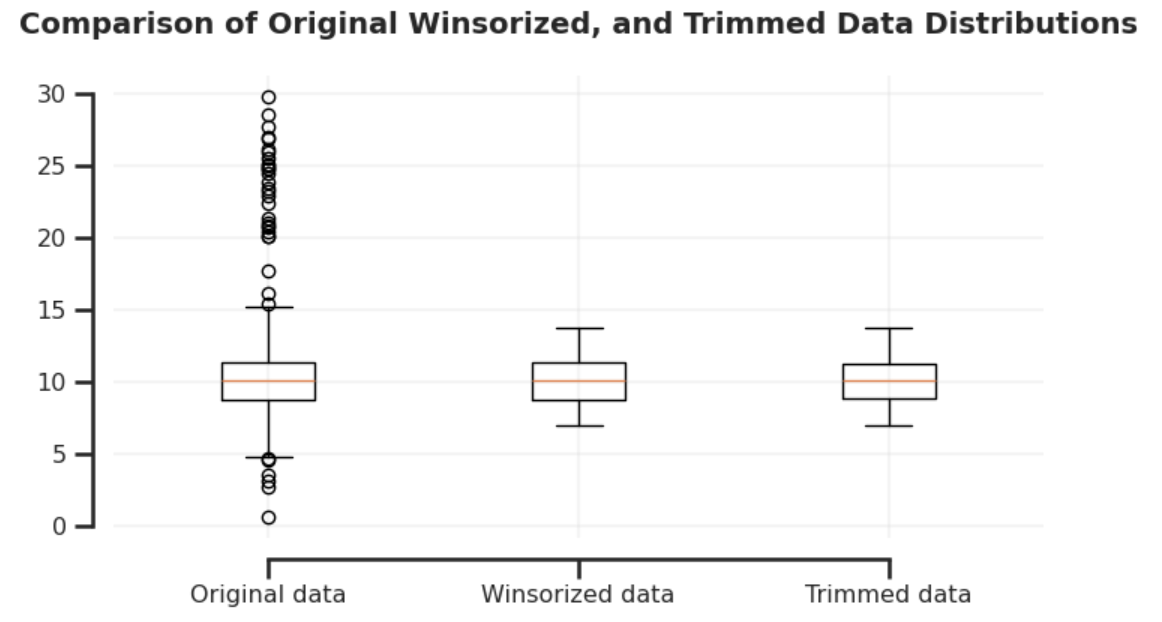

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define static data

df = pd.read_csv('/content/Newsalarydata.csv')
print(df)




    YearsExperience  Salary
0                 1   45000
1                 2   50000
2                 3   55000
3                 4   60000
4                 5   65000
5                 6   70000
6                 7   75000
7                 8   80000
8                 9   85000
9                10   90000
10                1  150000
11               15   30000


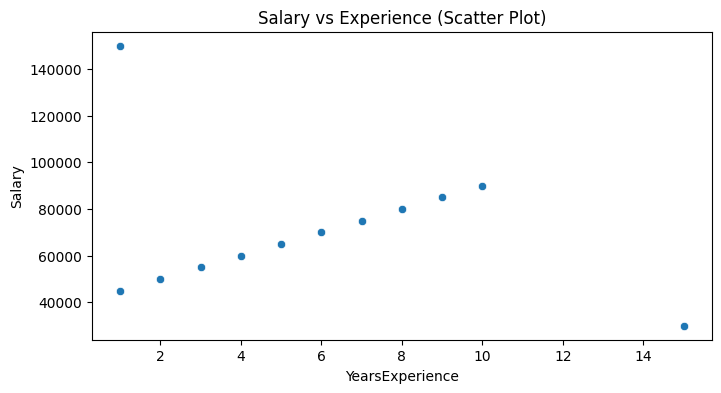

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='YearsExperience', y='Salary')
plt.title('Salary vs Experience (Scatter Plot)')
plt.savefig('scatter_plot.png')

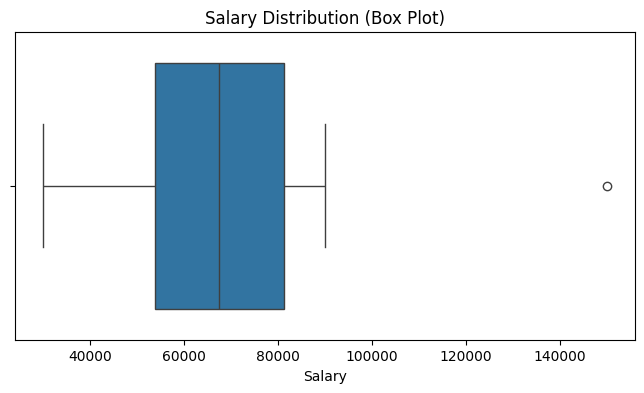

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Salary'])
plt.title('Salary Distribution (Box Plot)')
plt.savefig('box_plot.png')

**The order:**

**IQR (Detection)** $\rightarrow$ **Winsorization**



---

### 1. The Foundation: The IQR Method (Detection)

The Interquartile Range (IQR) is the most robust way to do this because it focuses on the **middle 50%** of your data.

* **The Concept:** Imagine your data sorted from smallest to largest.
* **Q1 (25th Percentile):** The value below which 25% of the data falls.
* **Q3 (75th Percentile):** The value below which 75% of the data falls.
* **IQR:** The distance between these two: $IQR = Q3 - Q1$.


* **The Fence Rule:** Any data point outside the following range is an outlier:
* **Lower Bound:** $Q1 - 1.5 \times IQR$
* **Upper Bound:** $Q3 + 1.5 \times IQR$


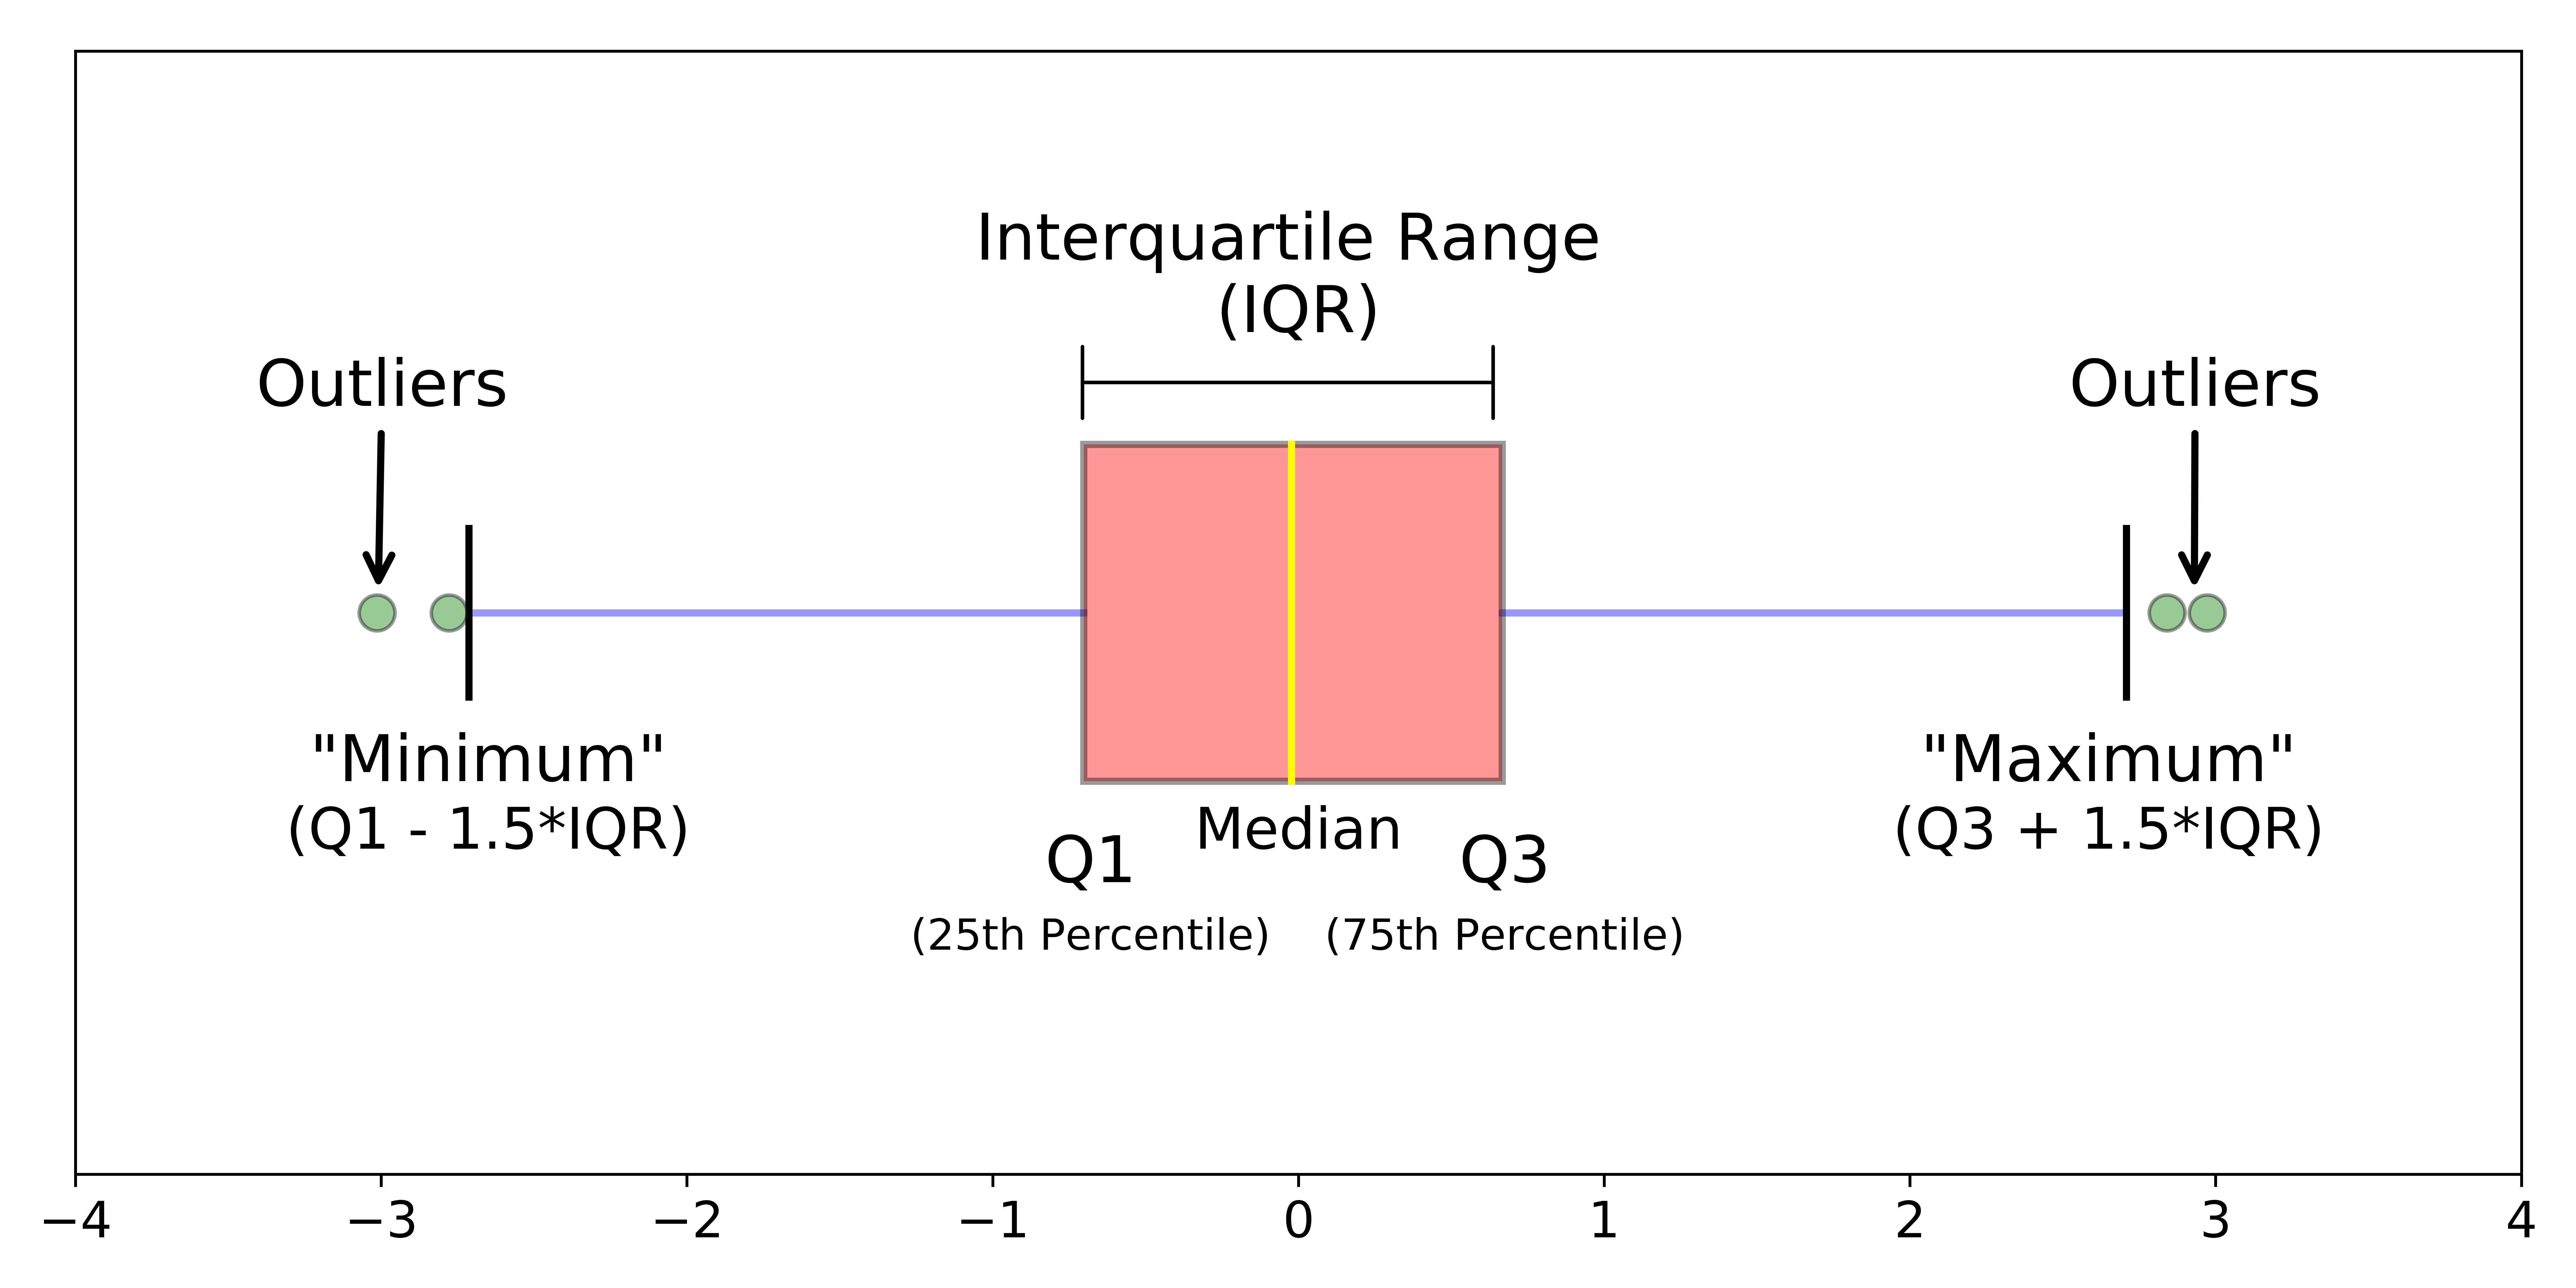



---

### 2. The Solution: Winsorization (Remediation)

* **Winsorization** is the smarter alternative. Instead of deleting (which loses data), you "CAP" or "CLIP" the outliers to a specific percentile.

* **The Concept:** If you perform 5th/95th percentile Winsorization, you take every value below the 5th percentile and replace it with the 5th percentile value. Every value above the 95th percentile is replaced with the 95th percentile value.
* **Why it's better:** It retains the sample size while reducing the influence of extreme values.

---





| Concept | Role | Why to know this first? |
| --- | --- | --- |
| **IQR** | **Diagnosis** | It uses the inherent spread of the data to objectively identify what "should" be considered normal. |
| **Winsorization** | **Treatment** | It is a "gentle" correction method that respects the original data distribution without discarding information. |

IQR is a **statistical filter**, and Winsorization is a **data transformation**. You always filter first to understand the problem, then transform to fix it.



In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('/content/Newsalarydata.csv')

# --- STEP 1: DETECT USING IQR ---
Q1 = df['Salary'].quantile(0.25)
print(Q1,'25% of Data')


Q3 = df['Salary'].quantile(0.75)
print(Q3,'75% of Data')

IQR = Q3 - Q1
print(IQR,'The IQR DAta')
lower_bound = Q1 - 1.5 * IQR



print(lower_bound,'By Substituting Q1')

upper_bound = Q3 + 1.5 * IQR

print(upper_bound,'By Substituting Q2')




# Replace values outside the 5th and 95th percentiles
lower_limit = df['Salary'].quantile(0.05)
upper_limit = df['Salary'].quantile(0.95)

print("*" * 45)

df['Salary_Winsorized'] = df['Salary'].clip(lower=lower_limit, upper=upper_limit)

print(f"Original Range: {df['Salary'].min()} to {df['Salary'].max()}")
print(f"Winsorized Range: {df['Salary_Winsorized'].min()} to {df['Salary_Winsorized'].max()}")

53750.0 25% of Data
81250.0 75% of Data
27500.0 The IQR DAta
12500.0 By Substituting Q1
122500.0 By Substituting Q2
*********************************************
Original Range: 30000 to 150000
Winsorized Range: 38250 to 117000


/tmp/ipykernel_487/1766211611.py:32: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Salary_Winsorized'] = df['Salary'].clip(lower=lower_limit, upper=upper_limit)


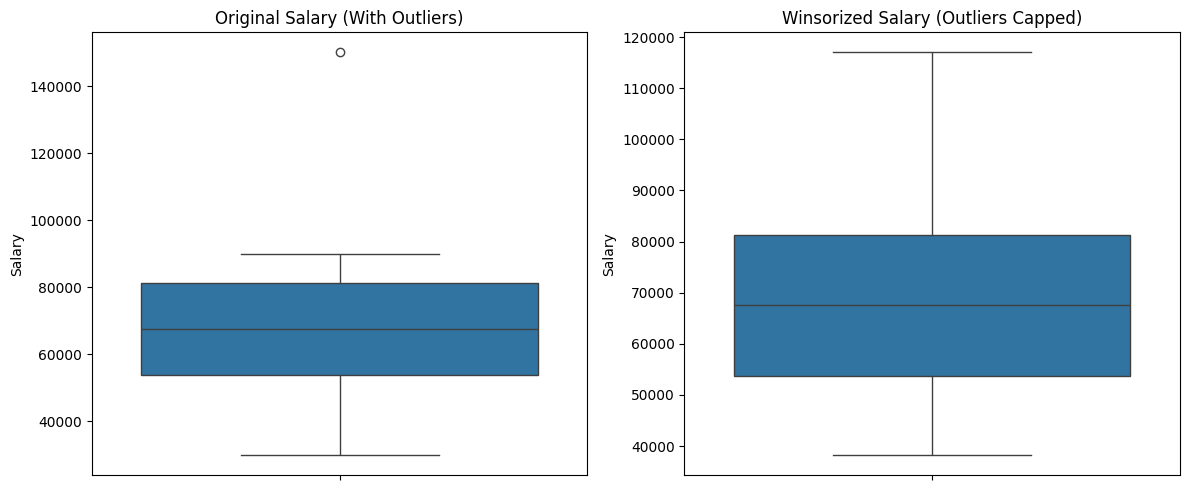

In [ ]:
# Visualization
plt.figure(figsize=(12, 5))

# Plot Original
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Salary'])
plt.title('Original Salary (With Outliers)')
plt.ylabel('Salary')

# Plot Winsorized
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Salary_Winsorized'])
plt.title('Winsorized Salary (Outliers Capped)')
plt.ylabel('Salary')

plt.tight_layout()

In [ ]:
import pandas as pd
from feature_engine.outliers import Winsorizer
# !pip install feature_engine

# 1. Load your dataset
df = pd.read_csv('/content/Newsalarydata.csv')

# 2. Set up the Winsorizer
# 'quantiles' strategy: replaces values with 5th and 95th percentiles
winsorizer = Winsorizer(capping_method='quantiles',
                        tail='both',
                        fold=0.05,
                        variables=['Salary'])

# 3. Fit and Transform
# The fit() method learns the 5th and 95th percentiles from the data
df_winsorized = winsorizer.fit_transform(df)

# 4. Check the results
print("Winsorizer Left Limit:", winsorizer.left_tail_caps_)
print("Winsorizer Right Limit:", winsorizer.right_tail_caps_)
print("\nFirst 5 rows of modified data:\n", df_winsorized)

Winsorizer Left Limit: {'Salary': 38250.0}
Winsorizer Right Limit: {'Salary': 116999.99999999996}

First 5 rows of modified data:
     YearsExperience  Salary
0                 1   45000
1                 2   50000
2                 3   55000
3                 4   60000
4                 5   65000
5                 6   70000
6                 7   75000
7                 8   80000
8                 9   85000
9                10   90000
10                1  117000
11               15   38250


/usr/local/lib/python3.12/dist-packages/feature_engine/outliers/base_outlier.py:87: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[feature] = X[feature].clip(upper=self.right_tail_caps_[feature])


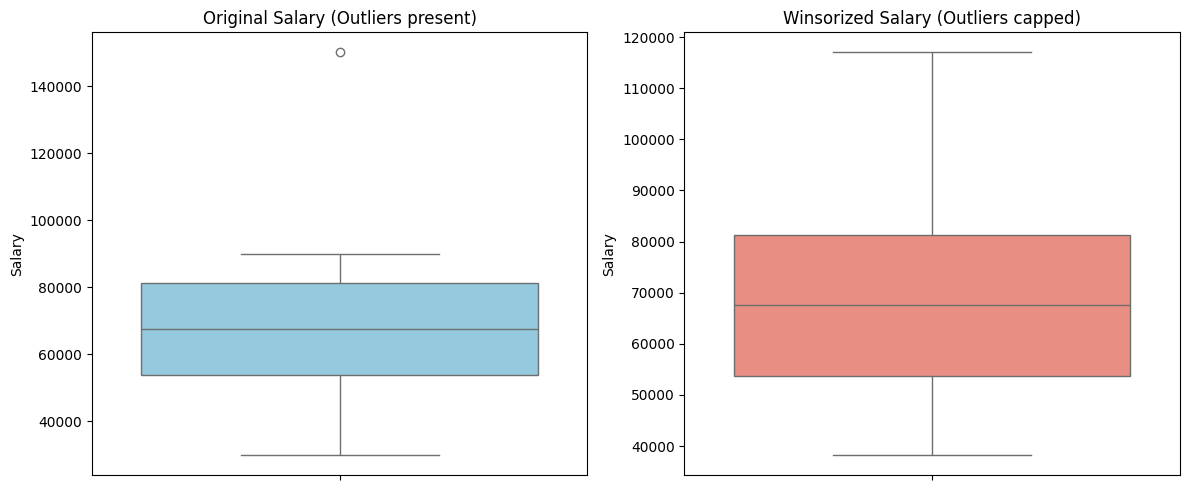

In [ ]:
# Set up the plot layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Original Salary
sns.boxplot(y=df['Salary'], ax=axes[0], color='skyblue')
axes[0].set_title('Original Salary (Outliers present)')

# Plot Winsorized Salary
sns.boxplot(y=df_winsorized['Salary'], ax=axes[1], color='salmon')
axes[1].set_title('Winsorized Salary (Outliers capped)')

plt.tight_layout()
plt.show()